In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, Model, optimizers
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from collections import Counter
from tqdm import tqdm
import re
import gc
from google.colab import drive
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import precision_recall_curve, roc_curve, roc_auc_score
import warnings
import openpyxl
import pickle
warnings.filterwarnings('ignore')

In [ ]:
# Enable memory growth for GPU
physical_devices = tf.config.experimental.list_physical_devices('GPU')
if len(physical_devices) > 0:
    tf.config.experimental.set_memory_growth(physical_devices[0], True)

# Mount Google Drive
drive.mount('/content/drive')

In [ ]:
class Config:
    # URLNet specifications
    CHAR_SEQ_LEN = 200      # URLNet character sequence length
    WORD_SEQ_LEN = 200      # URLNet word sequence length
    CHAR_IN_WORD_LEN = 20   # URLNet character-in-word length

    # Embedding dimensions
    EMBEDDING_DIM = 32

    # CNN parameters
    NUM_FILTERS = 256
    KERNEL_SIZE = 8
    POOL_SIZE = 2

    # Training parameters
    BATCH_SIZE = 128
    LEARNING_RATE = 0.001
    EPOCHS = 40
    DROPOUT_RATE = 0.5
    DENSE_UNITS = 128

    # Special tokens
    UNK_TOKEN = '<UNK>'
    PAD_TOKEN = '<PAD>'

    # Vocabulary thresholds
    MIN_CHAR_FREQ = 100
    MIN_WORD_FREQ = 2

config = Config()

In [ ]:
class MemoryEfficientURLPreprocessor:
    def __init__(self, max_vocab_size=10000):
        self.char_to_id = {}
        self.word_to_id = {}
        self.max_vocab_size = max_vocab_size

    def save(self, path):
        with open(path, 'wb') as f:
            pickle.dump({
                'char_to_id': self.char_to_id,
                'word_to_id': self.word_to_id,
                'max_vocab_size': self.max_vocab_size
            }, f)
        print(f"Preprocessor saved to {path}")

    def load(path):
        with open(path, 'rb') as f:
            data = pickle.load(f)

        pre = MemoryEfficientURLPreprocessor(max_vocab_size=data.get('max_vocab_size', 10000))
        pre.char_to_id = data['char_to_id']
        pre.word_to_id = data['word_to_id']
        print(f"Preprocessor loaded from {path}")
        return pre

    def load_data_from_excel(self, file_path, url_column='url', label_column='label', max_samples=None):
        """Load URL data from Excel file"""
        print("Loading URL data from Excel file...")

        try:
            # Read Excel file
            df = pd.read_excel(file_path)
            print(f"Excel file loaded with {len(df)} rows and columns: {list(df.columns)}")

            # Check if specified columns exist
            if url_column not in df.columns:
                print(f"Warning: Column '{url_column}' not found. Available columns: {list(df.columns)}")
                # Try to find URL column automatically
                possible_url_cols = [col for col in df.columns if 'url' in col.lower()]
                if possible_url_cols:
                    url_column = possible_url_cols[0]
                    print(f"Using column '{url_column}' as URL column")
                else:
                    raise ValueError("No URL column found")

            if label_column not in df.columns:
                print(f"Warning: Column '{label_column}' not found. Available columns: {list(df.columns)}")
                # Try to find label column automatically
                possible_label_cols = [col for col in df.columns if any(term in col.lower() for term in ['label', 'class', 'target', 'type'])]
                if possible_label_cols:
                    label_column = possible_label_cols[0]
                    print(f"Using column '{label_column}' as label column")
                else:
                    raise ValueError("No label column found")

            # Extract URLs and labels
            urls = df[url_column].astype(str).tolist()
            labels = df[label_column].tolist()

            # Handle different label formats
            unique_labels = set(labels)
            print(f"Unique labels found: {unique_labels}")

            # Convert labels to binary (0/1)
            if unique_labels == {0, 1} or unique_labels == {'0', '1'}:
                labels = [int(label) for label in labels]
            elif len(unique_labels) == 2:
                # Map to 0 and 1
                label_mapping = {list(unique_labels)[0]: 0, list(unique_labels)[1]: 1}
                labels = [label_mapping[label] for label in labels]
                print(f"Label mapping applied: {label_mapping}")
            else:
                raise ValueError(f"Expected binary labels, got: {unique_labels}")

            # Remove any NaN or empty URLs
            valid_indices = [i for i, url in enumerate(urls) if pd.notna(url) and str(url).strip() != '']
            urls = [urls[i] for i in valid_indices]
            labels = [labels[i] for i in valid_indices]

            # Limit samples if specified
            if max_samples and len(urls) > max_samples:
                urls = urls[:max_samples]
                labels = labels[:max_samples]

            print(f"Loaded {len(urls)} valid URLs")
            print(f"Benign URLs: {labels.count(0)}")
            print(f"Malicious URLs: {labels.count(1)}")

            return urls, labels

        except Exception as e:
            print(f"Error loading Excel data: {e}")
            return [], []

    def extract_characters(self, url):
        """Extract character sequence from URL"""
        return list(url.lower()[:config.CHAR_SEQ_LEN])

    def extract_words(self, url):
        """Extract word sequence from URL"""
        tokens = re.findall(r'[a-zA-Z0-9_-]+|[^a-zA-Z0-9_-]', url.lower())
        tokens = [token for token in tokens if token.strip()]
        return tokens[:config.WORD_SEQ_LEN]

    def build_vocabularies_efficient(self, urls, sample_size=10000):
        """Build vocabularies using sample of data"""
        print("Building vocabularies efficiently...")

        # Sample data to reduce memory usage
        if len(urls) > sample_size:
            sample_indices = np.random.choice(len(urls), sample_size, replace=False)
            sample_urls = [urls[i] for i in sample_indices]
        else:
            sample_urls = urls

        char_counter = Counter()
        word_counter = Counter()

        # Count in batches to save memory
        batch_size = 1000
        for i in tqdm(range(0, len(sample_urls), batch_size), desc="Building vocabularies"):
            batch_urls = sample_urls[i:i+batch_size]

            for url in batch_urls:
                chars = self.extract_characters(url)
                words = self.extract_words(url)

                char_counter.update(chars)
                word_counter.update(words)

            # Clear batch from memory
            del batch_urls
            if i % 5000 == 0:
                gc.collect()

        # Build character vocabulary
        self.char_to_id = {config.PAD_TOKEN: 0, config.UNK_TOKEN: 1}
        most_common_chars = char_counter.most_common()

        for char, count in most_common_chars:
            if count >= config.MIN_CHAR_FREQ and len(self.char_to_id) < self.max_vocab_size:
                self.char_to_id[char] = len(self.char_to_id)

        # Build word vocabulary
        self.word_to_id = {config.PAD_TOKEN: 0, config.UNK_TOKEN: 1}
        most_common_words = word_counter.most_common()

        for word, count in most_common_words:
            if count >= config.MIN_WORD_FREQ and len(self.word_to_id) < self.max_vocab_size:
                self.word_to_id[word] = len(self.word_to_id)

        print(f"Character vocabulary size: {len(self.char_to_id)}")
        print(f"Word vocabulary size: {len(self.word_to_id)}")

        # Clean up
        del char_counter, word_counter, sample_urls
        gc.collect()

    def encode_url_batch(self, urls):
        """Encode a batch of URLs efficiently"""
        batch_size = len(urls)

        # Initialize arrays
        char_sequences = np.zeros((batch_size, config.CHAR_SEQ_LEN), dtype=np.int32)
        word_sequences = np.zeros((batch_size, config.WORD_SEQ_LEN), dtype=np.int32)
        word_char_sequences = np.zeros((batch_size, config.WORD_SEQ_LEN, config.CHAR_IN_WORD_LEN), dtype=np.int32)

        for i, url in enumerate(urls):
            # Character sequence
            chars = self.extract_characters(url)
            for j_char, char in enumerate(chars[:config.CHAR_SEQ_LEN]):
                char_sequences[i, j_char] = self.char_to_id.get(char, self.char_to_id[config.UNK_TOKEN])

            # Word sequence + word-char sequence
            words = self.extract_words(url)
            for j, word in enumerate(words[:config.WORD_SEQ_LEN]):
                word_sequences[i, j] = self.word_to_id.get(word, self.word_to_id[config.UNK_TOKEN])

                # Word character sequence
                word_chars = list(word.lower())[:config.CHAR_IN_WORD_LEN]
                for k, ch in enumerate(word_chars):
                    word_char_sequences[i, j, k] = self.char_to_id.get(ch, self.char_to_id[config.UNK_TOKEN])

        return char_sequences, word_sequences, word_char_sequences

In [ ]:
def create_urlnet_model(char_vocab_size, word_vocab_size):
    """Create URLNet model"""

    # Input layers
    char_input = layers.Input(shape=(config.CHAR_SEQ_LEN,), name='char_input')
    word_input = layers.Input(shape=(config.WORD_SEQ_LEN,), name='word_input')
    word_char_input = layers.Input(shape=(config.WORD_SEQ_LEN, config.CHAR_IN_WORD_LEN), name='word_char_input')

    # Character embedding
    char_embedding = layers.Embedding(
        char_vocab_size,
        config.EMBEDDING_DIM,
        input_length=config.CHAR_SEQ_LEN,
        name='char_embedding'
    )(char_input)

    # Character CNN branch with multiple filter sizes
    char_convs = []
    for kernel_size in [3, 4, 5, 6]:
        conv = layers.Conv1D(
            filters=config.NUM_FILTERS,
            kernel_size=kernel_size,
            activation='relu'
        )(char_embedding)
        pool = layers.MaxPooling1D(pool_size=config.POOL_SIZE)(conv)
        flat = layers.Flatten()(pool)
        char_convs.append(flat)

    char_branch = layers.Concatenate()(char_convs)
    char_dense = layers.Dense(512, activation='relu')(char_branch)
    char_dropout = layers.Dropout(config.DROPOUT_RATE)(char_dense)

    # Word embedding
    word_embedding = layers.Embedding(
        word_vocab_size,
        config.EMBEDDING_DIM,
        input_length=config.WORD_SEQ_LEN,
        name='word_embedding'
    )(word_input)

    # Character-level word embedding
    word_char_embedding = layers.Embedding(
        char_vocab_size,
        config.EMBEDDING_DIM,
        name='word_char_embedding'
    )(word_char_input)

    word_char_sum = layers.Lambda(
        lambda x: tf.reduce_sum(x, axis=2),
        output_shape=(config.WORD_SEQ_LEN, config.EMBEDDING_DIM),
        name='word_char_sum'
    )(word_char_embedding)

    # Combine word embeddings
    combined_word_embedding = layers.Add(name='combined_word_embedding')([word_embedding, word_char_sum])

    # Word CNN branch with multiple filter sizes
    word_convs = []
    for kernel_size in [3, 4, 5, 6]:
        conv = layers.Conv1D(
            filters=config.NUM_FILTERS,
            kernel_size=kernel_size,
            activation='relu'
        )(combined_word_embedding)
        pool = layers.MaxPooling1D(pool_size=config.POOL_SIZE)(conv)
        flat = layers.Flatten()(pool)
        word_convs.append(flat)

    word_branch = layers.Concatenate()(word_convs)
    word_dense = layers.Dense(512, activation='relu')(word_branch)
    word_dropout = layers.Dropout(config.DROPOUT_RATE)(word_dense)

    # Combine branches
    combined = layers.Concatenate(name='combined_features')([char_dropout, word_dropout])

    # Final dense layers
    fc1 = layers.Dense(512, activation='relu')(combined)
    fc1_dropout = layers.Dropout(config.DROPOUT_RATE)(fc1)

    fc2 = layers.Dense(256, activation='relu')(fc1_dropout)
    fc2_dropout = layers.Dropout(config.DROPOUT_RATE)(fc2)

    fc3 = layers.Dense(128, activation='relu')(fc2_dropout)
    fc3_dropout = layers.Dropout(config.DROPOUT_RATE)(fc3)


    # Output layer
    output = layers.Dense(2, activation='softmax', name='output')(fc3_dropout)

    # Create model
    model = Model(
        inputs=[char_input, word_input, word_char_input],
        outputs=output,
        name='URLNet'
    )

    return model

In [ ]:
class SimpleDataGenerator:
    """Simple data generator for model"""

    def __init__(self, urls, labels, preprocessor, batch_size, shuffle=True):
        self.urls = urls
        self.labels = labels
        self.preprocessor = preprocessor
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.num_batches = len(urls) // batch_size
        self.reset()

    def reset(self):
        """Reset the generator for a new epoch"""
        self.indices = np.arange(len(self.urls))
        if self.shuffle:
            np.random.shuffle(self.indices)
        self.current_batch = 0

    def __iter__(self):
        return self

    def __next__(self):
        if self.current_batch >= self.num_batches:
            raise StopIteration

        start_idx = self.current_batch * self.batch_size
        end_idx = min(start_idx + self.batch_size, len(self.urls))

        batch_indices = self.indices[start_idx:end_idx]
        batch_urls = [self.urls[i] for i in batch_indices]
        batch_labels = [self.labels[i] for i in batch_indices]

        # Encode batch
        char_seq, word_seq, word_char_seq = self.preprocessor.encode_url_batch(batch_urls)
        batch_labels = np.array(batch_labels, dtype=np.int32)
        batch_labels = to_categorical(batch_labels, num_classes=2)

        self.current_batch += 1
        return [char_seq, word_seq, word_char_seq], batch_labels

    def __len__(self):
        return self.num_batches

In [ ]:
def train_model_with_generator(model, train_gen, val_gen, epochs):
    """Training loop with progress bars"""
    history = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': []}

    for epoch in range(epochs):
        print(f'\nEpoch {epoch + 1}/{epochs}')

        # Training
        train_gen.reset()
        epoch_loss = 0
        epoch_acc = 0
        batch_count = 0

        train_pbar = tqdm(total=len(train_gen), desc="Training",
                         bar_format='{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}, {rate_fmt}] Loss: {postfix[0]:.4f}, Acc: {postfix[1]:.4f}',
                         postfix=[0.0, 0.0])

        for batch_x, batch_y in train_gen:
            metrics = model.train_on_batch(batch_x, batch_y)
            epoch_loss += metrics[0]
            epoch_acc += metrics[1]
            batch_count += 1

            train_pbar.postfix[0] = metrics[0]
            train_pbar.postfix[1] = metrics[1]
            train_pbar.update(1)

        train_pbar.close()

        epoch_loss /= batch_count
        epoch_acc /= batch_count

        # Validation
        val_gen.reset()
        val_loss = 0
        val_acc = 0
        val_batch_count = 0

        val_pbar = tqdm(total=len(val_gen), desc="Validation",
                       bar_format='{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}, {rate_fmt}] Loss: {postfix[0]:.4f}, Acc: {postfix[1]:.4f}',
                       postfix=[0.0, 0.0])

        for batch_x, batch_y in val_gen:
            metrics = model.test_on_batch(batch_x, batch_y)
            val_loss += metrics[0]
            val_acc += metrics[1]
            val_batch_count += 1

            val_pbar.postfix[0] = metrics[0]
            val_pbar.postfix[1] = metrics[1]
            val_pbar.update(1)

        val_pbar.close()

        val_loss /= val_batch_count
        val_acc /= val_batch_count

        # Store history
        history['loss'].append(epoch_loss)
        history['accuracy'].append(epoch_acc)
        history['val_loss'].append(val_loss)
        history['val_accuracy'].append(val_acc)

        print(f'Epoch Summary - Loss: {epoch_loss:.4f} - Acc: {epoch_acc:.4f} - Val Loss: {val_loss:.4f} - Val Acc: {val_acc:.4f}')

    return history

In [ ]:
def evaluate_on_test_set(model, preprocessor, test_urls, test_labels, batch_size=128, title_prefix="Test"):
    """Evaluate model on test set and plot requested figures (accuracies match all-at-once)."""
    print("\n" + "="*60)
    print("FINAL EVALUATION ON TEST SET")
    print("="*60)

    # Encode entire dataset at once
    char_seq, word_seq, word_char_seq = preprocessor.encode_url_batch(test_urls)
    test_labels_array = np.array(test_labels, dtype=int)

    # Predict probabilities
    probs = model.predict([char_seq, word_seq, word_char_seq], batch_size=batch_size, verbose=1)  # shape (N,2)
    preds = np.argmax(probs, axis=1)
    malicious_probs = probs[:, 1]

    # Compute metrics
    accuracy = np.mean(preds == test_labels_array)
    print(f"\nTest Accuracy: {accuracy * 100:.4f}%")

    # Detailed classification report
    print("\nDetailed Classification Report:")
    print(classification_report(test_labels_array, preds,
                                target_names=['Benign', 'Malicious'],
                                digits=4))

    # ROC AUC
    auc_val = roc_auc_score(test_labels_array, malicious_probs)
    print(f"ROC AUC: {auc_val:.4f}")

    # Confusion matrix + plots
    plot_test_metrics(test_labels_array, malicious_probs, preds, title_prefix=title_prefix)

    return 0, accuracy, preds.tolist(), test_labels_array.tolist(), malicious_probs

In [ ]:
def predict_single_url(model, preprocessor, url, verbose=True):
    """Predict whether a single URL is malicious or benign (Softmax version)."""
    # Remove protocol (http:// or https://)
    url = re.sub(r"^https?://", "", url.strip(), flags=re.IGNORECASE)

    # Encode the URL
    char_seq, word_seq, word_char_seq = preprocessor.encode_url_batch([url])

    # Make prediction
    probs = model.predict([char_seq, word_seq, word_char_seq], verbose=0)[0]  # shape (2,)
    prediction = np.argmax(probs)          # 0 = Benign, 1 = Malicious
    prediction_prob = probs[1]             # Probability of class=Malicious
    confidence = probs[prediction] * 100   # Confidence in predicted class

    if verbose:
        label = "Malicious" if prediction == 1 else "Benign"
        print(f"URL: {url}")
        print(f"Prediction: {label}")
        print(f"Confidence: {confidence:.2f}%")
        print(f"Malicious Probability: {prediction_prob:.4f}")
        print("-" * 80)

    return prediction, prediction_prob, confidence

In [ ]:
def test_on_external_dataset(model, preprocessor, file_path, output_path):
    """Evaluate model on an external dataset (Softmax version)."""
    # Load external dataset
    urls, labels = preprocessor.load_data_from_excel(file_path)

    if not urls:
        print("No data found in the external dataset.")
        return

    print(f"Loaded external dataset with {len(urls)} samples")

    # Encode data batch
    char_seq, word_seq, word_char_seq = preprocessor.encode_url_batch(urls)

    # Run predictions
    predictions = model.predict([char_seq, word_seq, word_char_seq], verbose=1)  # shape (N,2)
    binary_preds = np.argmax(predictions, axis=1)   # Predicted class (0 or 1)
    malicious_probs = predictions[:, 1]             # Probability of malicious

    # Calculate accuracy
    accuracy = accuracy_score(labels, binary_preds)
    print(f"Accuracy on external dataset: {accuracy * 100:.2f}%")

    # Prepare DataFrame
    results_df = pd.DataFrame({
        "URL": urls,
        "True_Label": labels,
        "Predicted_Label": binary_preds,
        "Malicious_Probability": malicious_probs
    })

    # Save results to Excel
    results_df.to_excel(output_path, index=False)
    print(f"Results saved to {output_path}")

    return results_df, accuracy

In [ ]:
def build_model_from_preprocessor(preprocessor):
    model = create_urlnet_model(
        len(preprocessor.char_to_id),
        len(preprocessor.word_to_id)
    )
    model.compile(
        optimizer=optimizers.Adam(learning_rate=config.LEARNING_RATE),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

def load_artifacts(model_path, preproc_path):
    pre = MemoryEfficientURLPreprocessor.load(preproc_path)
    model = build_model_from_preprocessor(pre)
    model.load_weights(model_path)
    print("Model weights loaded.")
    return model, pre

def evaluate_saved_on_dataset(model_path, preproc_path, dataset_path, batch_size=128, title_prefix="Saved Model"):
    model, pre = load_artifacts(model_path, preproc_path)
    urls, labels = pre.load_data_from_excel(dataset_path)
    if not urls:
        print("No data to evaluate.")
        return
    return evaluate_on_test_set(model, pre, urls, labels, batch_size, title_prefix)

def predict_single_with_saved(model_path, preproc_path, url):
    model, pre = load_artifacts(model_path, preproc_path)
    return predict_single_url(model, pre, url, verbose=True)

In [ ]:
def plot_test_metrics(y_true, y_proba, y_pred=None, title_prefix="Test"):
    """
    Generate requested plots and metrics using test labels and predicted probabilities.

    Parameters:
        y_true (array-like): True binary labels (0/1).
        y_proba (array-like): Predicted probabilities for the positive class (shape: [n_samples]).
        y_pred (array-like, optional): Predicted binary labels (0/1). If None, uses 0.5 threshold.
        title_prefix (str): Prefix for plot titles (e.g., 'Test', 'External d2').
    """
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns

    if y_pred is None:
        y_pred = (np.asarray(y_proba) > 0.5).astype(int)

    y_true = np.asarray(y_true).astype(int)
    y_proba = np.asarray(y_proba).astype(float)

    # 1) Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Benign', 'Malicious'],
                yticklabels=['Benign', 'Malicious'])
    plt.title(f'{title_prefix} - Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()

    # 2) Precision–Recall Curve
    precisions, recalls, thresholds_pr = precision_recall_curve(y_true, y_proba)
    plt.figure(figsize=(6, 5))
    plt.plot(recalls, precisions, label='PR curve')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'{title_prefix} - Precision–Recall Curve')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # 3) Precision vs Confidence (Probability)
    # Bin probabilities into quantiles to stabilize curves
    bins = np.quantile(y_proba, np.linspace(0, 1, 21))  # 20 bins
    # Ensure unique bin edges to avoid errors
    bins = np.unique(bins)
    bin_ids = np.digitize(y_proba, bins[1:-1], right=True)

    bin_centers = []
    binned_precision = []
    binned_recall = []
    binned_f1 = []

    for b in range(bin_ids.min(), bin_ids.max() + 1):
        idx = np.where(bin_ids == b)[0]
        if idx.size == 0:
            continue
        p = y_proba[idx]
        t = y_true[idx]
        # Use 0.5 threshold within bin (or majority > 0.5)
        pred_bin = (p > 0.5).astype(int)

        tp = np.sum((pred_bin == 1) & (t == 1))
        fp = np.sum((pred_bin == 1) & (t == 0))
        fn = np.sum((pred_bin == 0) & (t == 1))

        precision = tp / (tp + fp) if (tp + fp) > 0 else np.nan
        recall = tp / (tp + fn) if (tp + fn) > 0 else np.nan
        f1 = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 and not np.isnan(precision) and not np.isnan(recall) else np.nan

        binned_precision.append(precision)
        binned_recall.append(recall)
        binned_f1.append(f1)
        bin_centers.append(np.mean(p))

    bin_centers = np.array(bin_centers)
    binned_precision = np.array(binned_precision)
    binned_recall = np.array(binned_recall)
    binned_f1 = np.array(binned_f1)

    # Precision vs Confidence
    plt.figure(figsize=(6, 5))
    plt.plot(bin_centers, binned_precision, marker='o')
    plt.xlabel('Confidence (Predicted Probability)')
    plt.ylabel('Precision')
    plt.title(f'{title_prefix} - Precision vs Confidence')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Recall vs Confidence
    plt.figure(figsize=(6, 5))
    plt.plot(bin_centers, binned_recall, marker='o', color='orange')
    plt.xlabel('Confidence (Predicted Probability)')
    plt.ylabel('Recall')
    plt.title(f'{title_prefix} - Recall vs Confidence')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # F1 vs Confidence
    plt.figure(figsize=(6, 5))
    plt.plot(bin_centers, binned_f1, marker='o', color='green')
    plt.xlabel('Confidence (Predicted Probability)')
    plt.ylabel('F1-score')
    plt.title(f'{title_prefix} - F1 vs Confidence')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # 4) ROC Curve + AUC
    fpr, tpr, thresholds_roc = roc_curve(y_true, y_proba)
    auc_val = roc_auc_score(y_true, y_proba)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f'ROC (AUC = {auc_val:.4f})')
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'{title_prefix} - ROC Curve')
    plt.legend(loc='lower right')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    fpr, tpr, thresholds_roc = roc_curve(y_true, y_proba)
    auc_val = roc_auc_score(y_true, y_proba)

    # Calculate and return metrics
    tn, fp, fn, tp = cm.ravel()

    accuracy = (tp + tn) / (tp + tn + fp + fn)
    precision_score = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall_score = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    f1_final = 2 * (precision_score * recall_score) / (precision_score + recall_score) if (precision_score + recall_score) > 0 else 0

    # Print metrics summary
    print(f"\n{'='*50}")
    print(f"METRICS SUMMARY FOR {title_prefix}")
    print(f"{'='*50}")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision_score:.4f}")
    print(f"Recall: {recall_score:.4f}")
    print(f"Specificity: {specificity:.4f}")
    print(f"F1 Score: {f1_final:.4f}")
    print(f"ROC AUC: {auc_val:.4f}")

In [ ]:
def main():
    # Set random seeds
    np.random.seed(42)
    tf.random.set_seed(42)

    # Clear session
    tf.keras.backend.clear_session()
    gc.collect()

    # Dataset path
    TRAIN_VAL_PATH = '/content/drive/MyDrive/Thesis/url_d1.xlsx'
    TEST_PATH = '/content/drive/MyDrive/Thesis/url_d3.xlsx'

    # Artifacts
    MODEL_PATH = '/content/drive/MyDrive/Final_Thesis/urlnet_model.keras'
    PREPROC_PATH = '/content/drive/MyDrive/Final_Thesis/urlnet_preprocessor.pkl'

    # Initialize preprocessor
    preprocessor = MemoryEfficientURLPreprocessor(max_vocab_size=10000)

    # Train/Val from d1
    urls, labels = preprocessor.load_data_from_excel(TRAIN_VAL_PATH)
    if not urls:
        print("Failed to load data. Please check the file path and format.")
        return

    train_urls, val_urls, train_labels, val_labels = train_test_split(
        urls, labels, test_size=0.2, random_state=42, stratify=labels
    )

    print(f"Training samples: {len(train_urls)}")
    print(f"Validation samples: {len(val_urls)}")

    # Build vocabularies
    preprocessor.build_vocabularies_efficient(train_urls)

    # Create model
    print("Creating URLNet model...")
    model = create_urlnet_model(
        len(preprocessor.char_to_id),
        len(preprocessor.word_to_id)
    )

    # Compile model
    model.compile(
        optimizer=optimizers.Adam(learning_rate=config.LEARNING_RATE),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    print(f"Model parameters: {model.count_params():,}")
    model.summary()

    # Create data generators
    train_generator = SimpleDataGenerator(
        train_urls, train_labels, preprocessor, config.BATCH_SIZE, shuffle=True
    )

    val_generator = SimpleDataGenerator(
        val_urls, val_labels, preprocessor, config.BATCH_SIZE, shuffle=False
    )

    # Train model
    print("Training URLNet model...")
    history = train_model_with_generator(model, train_generator, val_generator, config.EPOCHS)

    # Save artifacts
    model.save(MODEL_PATH)
    print(f"Model saved to {MODEL_PATH}")
    preprocessor.save(PREPROC_PATH)

    # Test on d3
    test_urls, test_labels = preprocessor.load_data_from_excel(TEST_PATH)
    if not test_urls:
        print("Failed to load test data from d3. Please check the file path and format.")
        return

    # Plot training history
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(history['loss'], label='Training Loss')
    plt.plot(history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history['accuracy'], label='Training Accuracy')
    plt.plot(history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.show()


    # test
    test_loss, test_accuracy, test_predictions, test_true_labels, test_probabilities = evaluate_on_test_set(
        model, preprocessor, test_urls, test_labels, config.BATCH_SIZE, title_prefix="URLNet"
    )

    external_results = test_on_external_dataset(
        model,
        preprocessor,
        "/content/drive/MyDrive/Thesis/url_d2.xlsx",
        "/content/drive/MyDrive/Final_Thesis/url_results_d2.xlsx"
    )

    external_results2 = test_on_external_dataset(
        model,
        preprocessor,
        "/content/drive/MyDrive/Thesis/url_d3.xlsx",
        "/content/drive/MyDrive/Final_Thesis/url_results_d3.xlsx"
    )

    predict_single_url(model, preprocessor, "https://vegamovies.moi/download-nymph-2014-hindi-org-english-480p-720p-1080p-bluray", verbose=True)

    return model, preprocessor, history

Loading URL data from Excel file...
Excel file loaded with 20000 rows and columns: ['label', 'url']
Unique labels found: {0, 1}
Loaded 20000 valid URLs
Benign URLs: 10000
Malicious URLs: 10000
Training samples: 16000
Validation samples: 4000
Building vocabularies efficiently...


Building vocabularies: 100%|██████████| 10/10 [00:00<00:00, 20.12it/s]


Character vocabulary size: 50
Word vocabulary size: 3966
Creating URLNet model...
Model parameters: 103,877,826


Model: "URLNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ word_char_input     │ (None, 200, 20)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ word_input          │ (None, 200)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ word_char_embedding │ (None, 200, 20,   │      1,600 │ word_char_input[… │
│ (Embedding)         │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ char_input          │ (None, 200)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ word_embedding      │ (None, 200, 32)   │    126,912 │ word_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ word_char_sum       │ (None, 200, 32)   │          0 │ word_char_embedd… │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ char_embedding      │ (None, 200, 32)   │      1,600 │ char_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ combined_word_embe… │ (None, 200, 32)   │          0 │ word_embedding[0… │
│ (Add)               │                   │            │ word_char_sum[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 198, 256)  │     24,832 │ char_embedding[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 197, 256)  │     33,024 │ char_embedding[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 196, 256)  │     41,216 │ char_embedding[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 195, 256)  │     49,408 │ char_embedding[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 198, 256)  │     24,832 │ combined_word_em… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 197, 256)  │     33,024 │ combined_word_em… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_6 (Conv1D)   │ (None, 196, 256)  │     41,216 │ combined_word_em… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_7 (Conv1D)   │ (None, 195, 256)  │     49,408 │ combined_word_em… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 99, 256)   │          0 │ conv1d[0][0]      │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_1     │ (None, 98, 256)   │          0 │ conv1d_1[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_2     │ (None, 98, 256)   │          0 │ conv1d_2[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

...

Epoch Summary - Loss: 0.0806 - Acc: 0.9787 - Val Loss: 0.0805 - Val Acc: 0.9789

Epoch 39/40


Validation: 100%|██████████| 31/31 [00:00<00:00, 54.45it/s] Loss: 0.0803, Acc: 0.9791


Epoch Summary - Loss: 0.0802 - Acc: 0.9790 - Val Loss: 0.0799 - Val Acc: 0.9791

Epoch 40/40


Validation: 100%|██████████| 31/31 [00:00<00:00, 52.23it/s] Loss: 0.0794, Acc: 0.9794


Epoch Summary - Loss: 0.0795 - Acc: 0.9793 - Val Loss: 0.0791 - Val Acc: 0.9795
Model saved to /content/drive/MyDrive/Final_Thesis/urlnet_model.keras
Preprocessor saved to /content/drive/MyDrive/Final_Thesis/urlnet_preprocessor.pkl
Loading URL data from Excel file...
Excel file loaded with 9373 rows and columns: ['label', 'url']
Unique labels found: {0, 1}
Loaded 9373 valid URLs
Benign URLs: 4687
Malicious URLs: 4686


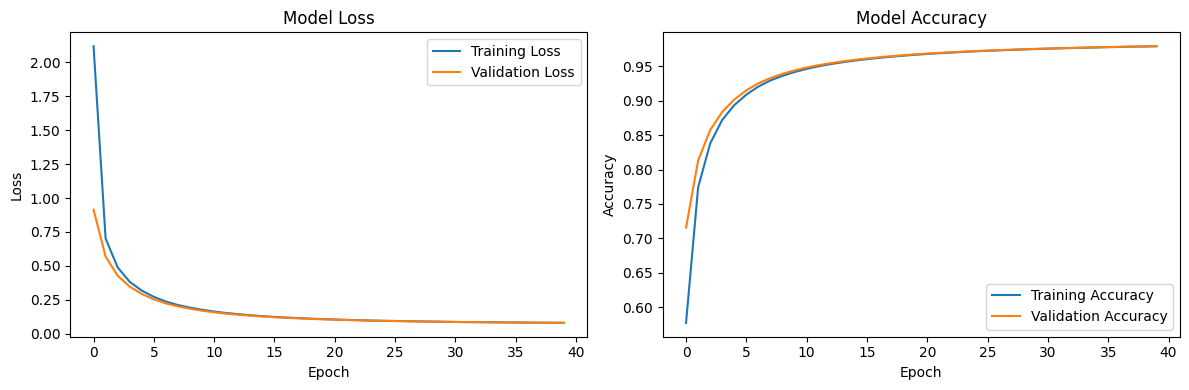


FINAL EVALUATION ON TEST SET
74/74 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step

Test Accuracy: 95.6257%

Detailed Classification Report:
              precision    recall  f1-score   support

      Benign     0.9626    0.9494    0.9560      4687
   Malicious     0.9501    0.9631    0.9565      4686

    accuracy                         0.9563      9373
   macro avg     0.9563    0.9563    0.9563      9373
weighted avg     0.9563    0.9563    0.9563      9373

ROC AUC: 0.9907


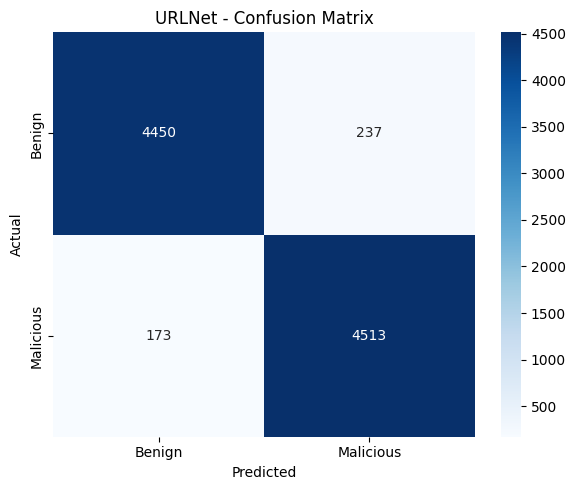

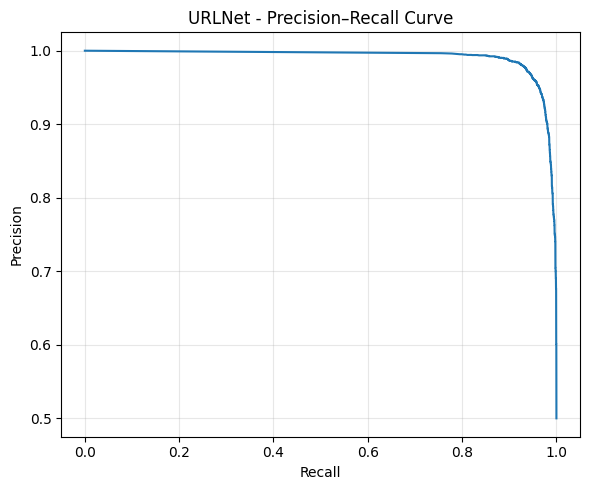

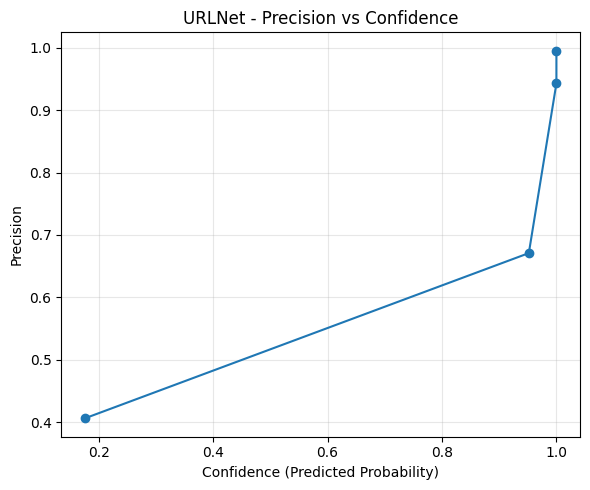

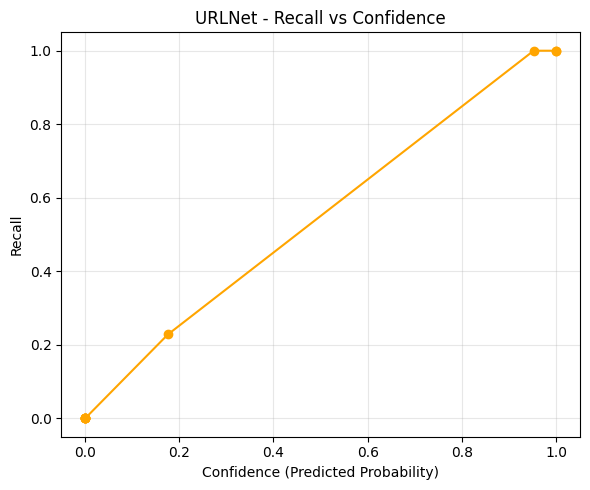

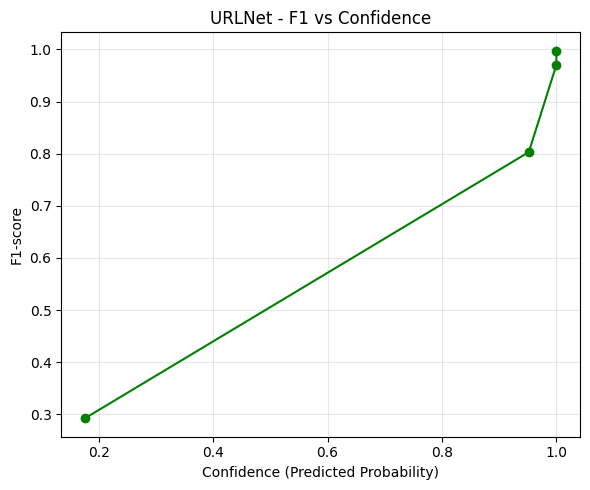

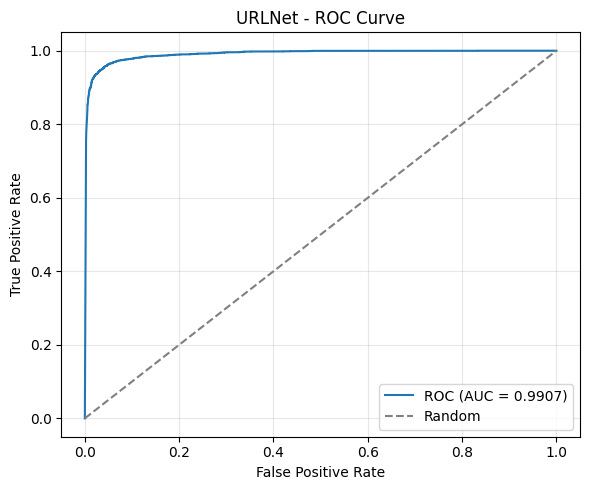


METRICS SUMMARY FOR URLNet
Accuracy: 0.9563
Precision: 0.9501
Recall: 0.9631
Specificity: 0.9494
F1 Score: 0.9565
ROC AUC: 0.9907
Loading URL data from Excel file...
Excel file loaded with 16000 rows and columns: ['label', 'url']
Unique labels found: {0, 1}
Loaded 16000 valid URLs
Benign URLs: 8000
Malicious URLs: 8000
Loaded external dataset with 16000 samples
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step
Accuracy on external dataset: 95.68%
Results saved to /content/drive/MyDrive/Final_Thesis/url_results_d2.xlsx
Loading URL data from Excel file...
Excel file loaded with 9373 rows and columns: ['label', 'url']
Unique labels found: {0, 1}
Loaded 9373 valid URLs
Benign URLs: 4687
Malicious URLs: 4686
Loaded external dataset with 9373 samples
293/293 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
Accuracy on external dataset: 95.63%
Results saved to /content/drive/MyDrive/Final_Thesis/url_results_d3.xlsx
URL: vegamovies.moi/download-nymph-2014-hindi-org-english-480p-720p-1080p-bluray
Prediction: Benign
Co

In [ ]:
if __name__ == "__main__":
    model, preprocessor, history = main()
    print("\nURLNet model training completed!")

In [ ]:
MODEL_PATH = '/content/drive/MyDrive/Final_Thesis/urlnet_model.keras'
PREPROC_PATH = '/content/drive/MyDrive/Final_Thesis/urlnet_preprocessor.pkl'

Preprocessor loaded from /content/drive/MyDrive/Final_Thesis/urlnet_preprocessor.pkl
Model weights loaded.
Loading URL data from Excel file...
Excel file loaded with 9373 rows and columns: ['label', 'url']
Unique labels found: {0, 1}
Loaded 9373 valid URLs
Benign URLs: 4687
Malicious URLs: 4686

FINAL EVALUATION ON TEST SET
74/74 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step

Test Accuracy: 95.6257%

Detailed Classification Report:
              precision    recall  f1-score   support

      Benign     0.9626    0.9494    0.9560      4687
   Malicious     0.9501    0.9631    0.9565      4686

    accuracy                         0.9563      9373
   macro avg     0.9563    0.9563    0.9563      9373
weighted avg     0.9563    0.9563    0.9563      9373

ROC AUC: 0.9907


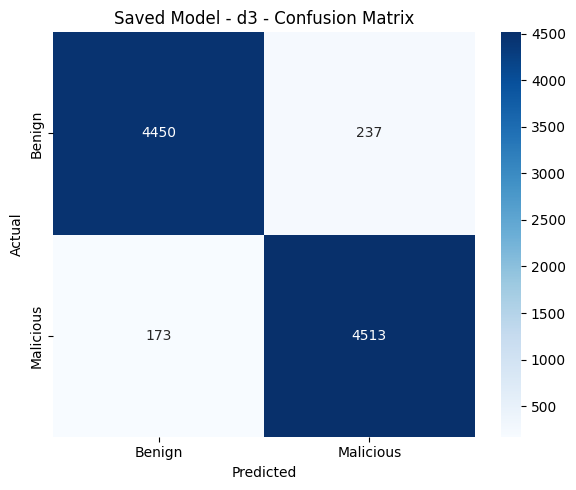

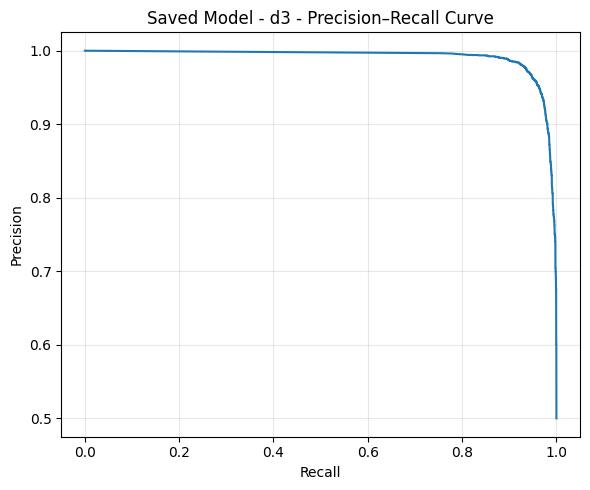

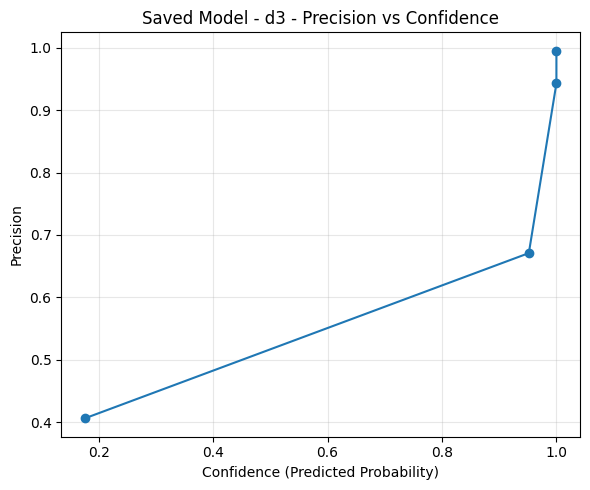

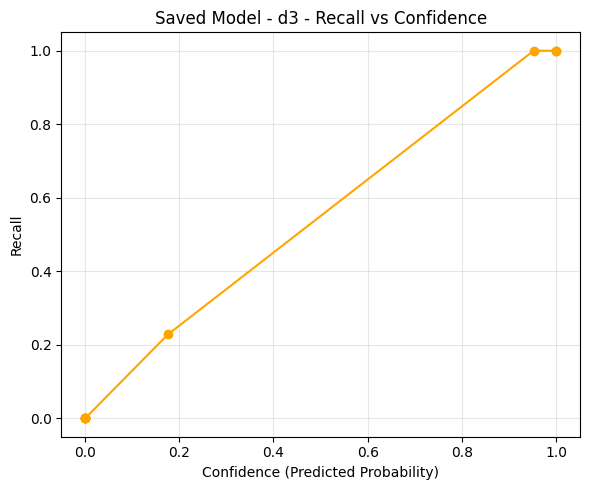

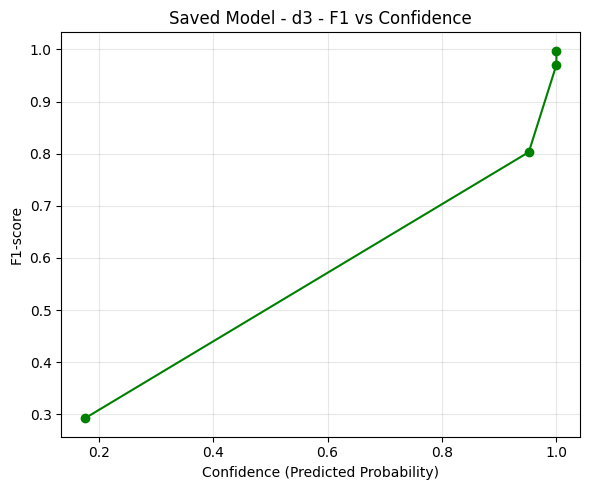

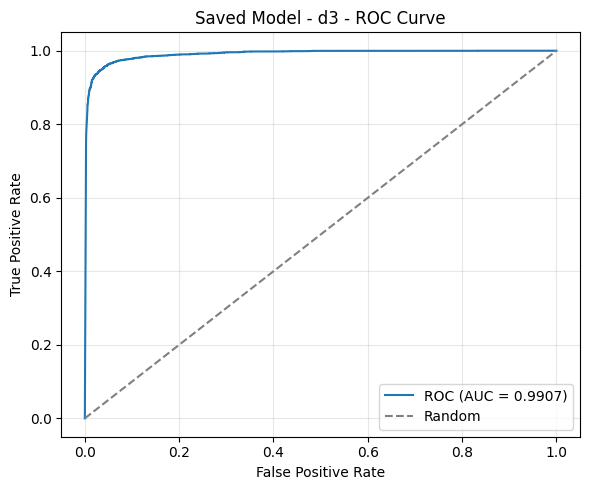


METRICS SUMMARY FOR Saved Model - d3
Accuracy: 0.9563
Precision: 0.9501
Recall: 0.9631
Specificity: 0.9494
F1 Score: 0.9565
ROC AUC: 0.9907


In [ ]:
test_loss, test_accuracy, test_predictions, test_true_labels, test_probabilities = evaluate_saved_on_dataset(
    MODEL_PATH,
    PREPROC_PATH,
    '/content/drive/MyDrive/Thesis/url_d3.xlsx',
    batch_size=128,
    title_prefix="Saved Model - d3"
)

In [ ]:
# Ask the user for a URL
# "https://vegamovies.moi/download-nymph-2014-hindi-org-english-480p-720p-1080p-bluray"
# "http://secureupdate.appleld.com.duilawyeryork.com/ap/88b142e778d73f7"
user_url = input("Enter the URL: ")

# Call the prediction function with the user-provided URL
predict_single_with_saved(
    MODEL_PATH,
    PREPROC_PATH,
    user_url
)

Enter the URL: https://app.outlier.ai/expert
Preprocessor loaded from /content/drive/MyDrive/Final_Thesis/urlnet_preprocessor.pkl
Model weights loaded.
URL: app.outlier.ai/expert
Prediction: Benign
Confidence: 96.34%
Malicious Probability: 0.0366
--------------------------------------------------------------------------------


(np.int64(0), np.float32(0.036582362), np.float32(96.34176))

In [ ]:
predict_single_with_saved(
    MODEL_PATH,
    PREPROC_PATH,
    "https://vegamovies.moi/download-nymph-2014-hindi-org-english-480p-720p-1080p-bluray"
)
predict_single_with_saved(
    MODEL_PATH,
    PREPROC_PATH,
    "http://secureupdate.appleld.com.duilawyeryork.com/ap/88b142e778d73f7"
)

Preprocessor loaded from /content/drive/MyDrive/Final_Thesis/urlnet_preprocessor.pkl
Model weights loaded.
URL: vegamovies.moi/download-nymph-2014-hindi-org-english-480p-720p-1080p-bluray
Prediction: Benign
Confidence: 99.95%
Malicious Probability: 0.0005
--------------------------------------------------------------------------------
Preprocessor loaded from /content/drive/MyDrive/Final_Thesis/urlnet_preprocessor.pkl
Model weights loaded.
URL: secureupdate.appleld.com.duilawyeryork.com/ap/88b142e778d73f7
Prediction: Malicious
Confidence: 100.00%
Malicious Probability: 1.0000
--------------------------------------------------------------------------------


(np.int64(1), np.float32(1.0), np.float32(100.0))